# 15 — ACSM: chemical speciation

**Theme:** what the aerosol mass is *made of*, rather than how large it is.

An Aerosol Chemical Speciation Monitor vaporises the non-refractory submicron
aerosol and measures the mass of each chemical species. Where a sizing
instrument tells you about particle diameter, this tells you about composition —
the two are complementary.

In [1]:
import matplotlib.pyplot as plt

import aerosoltools as at

acsm = at.load_simple_acsm_file("../../tests/data/Sample_ACSM.csv")

print("instrument:", acsm.instrument)
print("columns   :", list(acsm.data))
print("unit      :", acsm.unit)
print("samples   :", len(acsm.data))

instrument: ACSM
columns   : ['Org', 'SO4', 'NO3', 'NH4', 'Chlorine', 'All data']
unit      : µg/m³
samples   : 16838


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The species

Five species are reported, each as a mass concentration.

In [2]:
for name in ["org", "sulfate", "nitrate", "ammonia", "chlorine"]:
    series = getattr(acsm, name)
    print(f"{name:9s} mean {series.mean():8.3f}   max {series.max():8.3f}")

org       mean    1.523   max   37.967
sulfate   mean    0.307   max    1.604
nitrate   mean    0.164   max    1.530
ammonia   mean    0.103   max    1.849
chlorine  mean    0.031   max    4.757


Organics usually dominate submicron mass, with sulfate and nitrate next.
Chlorine is typically minor except near specific sources.

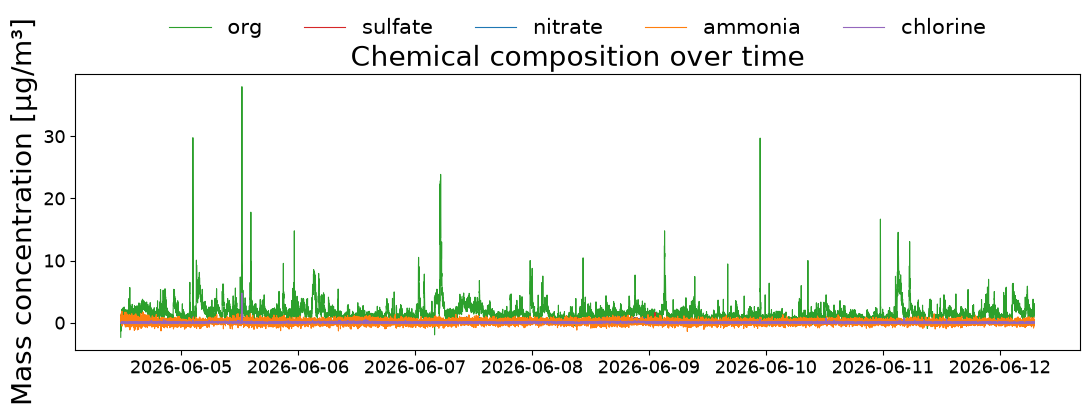

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, colour in [("org", "tab:green"), ("sulfate", "tab:red"),
                     ("nitrate", "tab:blue"), ("ammonia", "tab:orange"),
                     ("chlorine", "tab:purple")]:
    ax.plot(acsm.time, getattr(acsm, name), label=name, lw=0.8, color=colour)
ax.set_ylabel(f"Mass concentration [{acsm.unit}]")
ax.set_title("Chemical composition over time")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()

## Composition as a whole

The relative contributions are usually more informative than the absolute
values, because they are what distinguishes one source or air mass from another.

In [4]:
species = ["org", "sulfate", "nitrate", "ammonia", "chlorine"]
means = {name: getattr(acsm, name).mean() for name in species}
total = sum(means.values())

for name, value in means.items():
    print(f"{name:9s} {value:8.3f}  ({100 * value / total:5.1f} %)")

org          1.523  ( 71.6 %)
sulfate      0.307  ( 14.4 %)
nitrate      0.164  (  7.7 %)
ammonia      0.103  (  4.8 %)
chlorine     0.031  (  1.5 %)


Text(0.5, 1.0, 'Mean submicron composition')

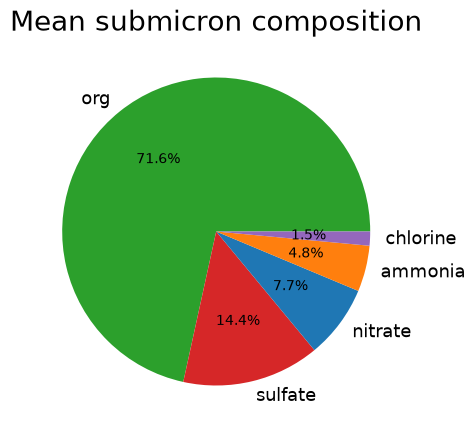

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(means.values(), labels=list(means), autopct="%1.1f%%",
       colors=["tab:green", "tab:red", "tab:blue", "tab:orange", "tab:purple"])
ax.set_title("Mean submicron composition")

Negative values appear in ACSM data — they are the noise of a difference
measurement around a small signal, not physically negative mass. They matter
when averaging over short periods, where they can dominate; over longer periods
they average out.

## Summarising every species

`summarize_activities` reports only the dataset's *default* metric unless told
otherwise, and for an ACSM that default is the organic fraction — the largest
single component.

In [6]:
acsm.available_metrics()

[MetricSpec(key='Org', label='Org', unit='µg/m³', dimension='mass', default=True),
 MetricSpec(key='SO4', label='SO4', unit='µg/m³', dimension='mass', default=False),
 MetricSpec(key='NO3', label='NO3', unit='µg/m³', dimension='mass', default=False),
 MetricSpec(key='NH4', label='NH4', unit='µg/m³', dimension='mass', default=False),
 MetricSpec(key='Chlorine', label='Chlorine', unit='µg/m³', dimension='mass', default=False)]

`default=True` on `Org` alone is why a plain call reports only that species. For
a speciation instrument you almost always want all of them, so name them
explicitly.

In [7]:
midpoint = len(acsm.time) // 2
acsm.mark_activities({
    "First half":  [(str(acsm.time[0]), str(acsm.time[midpoint]))],
    "Second half": [(str(acsm.time[midpoint + 1]), str(acsm.time[-1]))],
})

acsm.summarize_activities(metrics=["Org", "SO4", "NO3", "NH4", "Chlorine"])


Summary of aerosol metrics per activity:

+-----------------------+----------+------------+-------------+
|                       | All data | First half | Second half |
+-----------------------+----------+------------+-------------+
|   Duration (HH:MM)    |  187:29  |   93:50    |    93:38    |
|   Org [µg/m³] mean    |  1.523   |   1.748    |    1.299    |
|    Org [µg/m³] std    |  1.451   |   1.628    |    1.21     |
|   SO4 [µg/m³] mean    |  0.307   |   0.329    |    0.285    |
|    SO4 [µg/m³] std    |  0.144   |   0.142    |    0.142    |
|   NO3 [µg/m³] mean    |  0.164   |   0.187    |    0.141    |
|    NO3 [µg/m³] std    |  0.163   |   0.163    |    0.159    |
|   NH4 [µg/m³] mean    |  0.103   |   0.118    |    0.088    |
|    NH4 [µg/m³] std    |  0.354   |   0.377    |    0.329    |
| Chlorine [µg/m³] mean |  0.031   |   0.038    |    0.025    |
| Chlorine [µg/m³] std  |  0.081   |    0.09    |    0.07     |
+-----------------------+----------+------------+------------

,Segment,Duration (HH:MM),Org [µg/m³] mean,Org [µg/m³] std,SO4 [µg/m³] mean,SO4 [µg/m³] std,NO3 [µg/m³] mean,NO3 [µg/m³] std,NH4 [µg/m³] mean,NH4 [µg/m³] std,Chlorine [µg/m³] mean,Chlorine [µg/m³] std
0,All data,187:29,1.523,1.451,0.307,0.144,0.164,0.163,0.103,0.354,0.031,0.081
1,First half,93:50,1.748,1.628,0.329,0.142,0.187,0.163,0.118,0.377,0.038,0.090
2,Second half,93:38,1.299,1.210,0.285,0.142,0.141,0.159,0.088,0.329,0.025,0.070


The metric keys are the column names, which `available_metrics` lists — note
they are the instrument's own labels (`SO4`, `NH4`), not the accessor names
(`sulfate`, `ammonia`).

## It is a non-particle class

The ACSM measures mass by species, not a particle number concentration, so
`total_concentration` deliberately raises.

In [8]:
try:
    acsm.total_concentration
except AttributeError as err:
    print("AttributeError:", str(err)[:120])

AttributeError: ACSM_simple does not measure particle number, so it has no 'total_concentration'. Use this class's dedicated accessor or


## Rebinning

Rebinning is often the first thing to do with an ACSM record: the instrument
samples every 30 seconds or so, and composition rarely changes that fast, so
averaging to a few minutes suppresses the noise without losing signal.

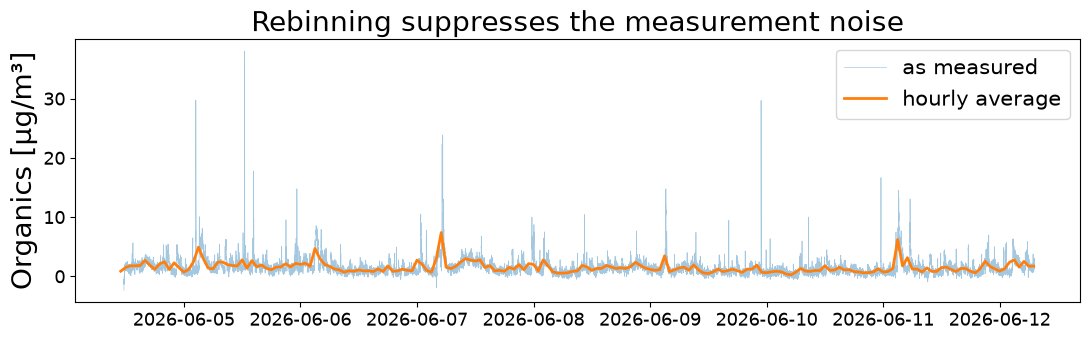

In [9]:
hourly = acsm.timerebin("1h", inplace=False)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(acsm.time, acsm.org, lw=0.5, alpha=0.4, label="as measured")
ax.plot(hourly.time, hourly.org, lw=2, label="hourly average")
ax.set_ylabel(f"Organics [{acsm.unit}]")
ax.legend(loc="upper right")
ax.set_title("Rebinning suppresses the measurement noise")
plt.tight_layout()

---

That is the end of the current examples. The weather-station notebook (14) is
still to come.